# Synthetic Control — California Prop 99

Estimates the effect of California's 1988 tobacco control program (Proposition 99)
on per-capita cigarette sales using the synthetic control method (Abadie, Diamond & Hainmueller 2010).

| | |
|---|---|
| **Treatment** | Proposition 99 — California's 1988 tobacco tax and anti-smoking campaign |
| **Treated unit** | California |
| **Outcome** | `cigsale` — per-capita cigarette sales (packs per year) |
| **Pre-treatment** | 1970–1988 |
| **Post-treatment** | 1989–2000 |
| **Donor pool** | 38 U.S. states that did not pass similar legislation |
| **Dataset** | Abadie, Diamond & Hainmueller (2010) replication data |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv(Path("../data/raw/smoking.csv"))

ca_id     = int(df.loc[df["california"], "state"].iloc[0])
donor_ids = sorted(df.loc[~df["california"], "state"].unique().tolist())

print(f"California state ID : {ca_id}")
print(f"Donor states        : {len(donor_ids)}")
print(f"Years               : {df['year'].min()}–{df['year'].max()}")
print(f"Shape               : {df.shape}")
df.head()

California state ID : 3
Donor states        : 38
Years               : 1970–2000
Shape               : (1209, 9)


,state,year,cigsale,lnincome,beer,age15to24,retprice,california,after_treatment
0,1,1970,89.800003,NaN,NaN,0.178862,39.599998,False,False
1,1,1971,95.400002,NaN,NaN,0.179928,42.700001,False,False
2,1,1972,101.099998,9.498476,NaN,0.180994,42.299999,False,False
3,1,1973,102.900002,9.550107,NaN,0.182060,42.099998,False,False
4,1,1974,108.199997,9.537163,NaN,0.183126,43.099998,False,False


## Predictor choice

`lnincome`, `beer`, and `age15to24` have substantial missing values across the donor pool
and cannot be used reliably. Predictors used here:

- **`cigsale` at 1975, 1980, 1988** — lagged outcome values (following ADH Table 1)
- **`retprice` pre-treatment average** — retail cigarette price; complete for all states

The cigsale lags carry most of the identification weight in the original paper anyway.

In [3]:
T0             = 1988          # last pre-treatment year
OUTCOME        = "cigsale"
PREDICTOR_LAGS = [1975, 1980, 1988]
PREDICTOR_COVS = ["retprice"]

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
state                0
year                 0
cigsale              0
lnincome           195
beer               663
age15to24          390
retprice             0
california           0
after_treatment      0
dtype: int64


## Raw trends

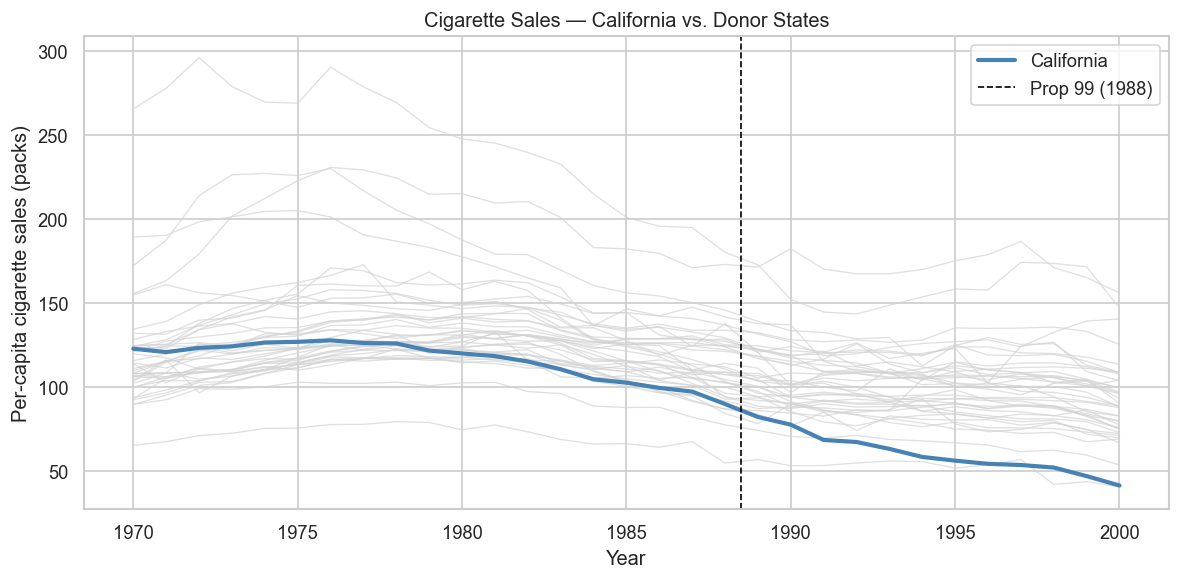

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

for sid in donor_ids:
    s = df[df["state"] == sid]
    ax.plot(s["year"], s[OUTCOME], color="lightgrey", linewidth=0.8, alpha=0.7)

ca = df[df["california"]]
ax.plot(ca["year"], ca[OUTCOME], color="steelblue", linewidth=2.5, label="California")
ax.axvline(T0 + 0.5, color="black", linestyle="--", linewidth=1, label="Prop 99 (1988)")
ax.set_xlabel("Year")
ax.set_ylabel("Per-capita cigarette sales (packs)")
ax.set_title("Cigarette Sales — California vs. Donor States")
ax.legend()
plt.tight_layout()
plt.show()

## Build predictor and outcome matrices

In [5]:
# Pivot to wide format: rows = years, columns = state IDs
Y_wide = df.pivot(index="year", columns="state", values=OUTCOME)
years  = Y_wide.index.values

pre_mask  = years <= T0
post_mask = years >  T0

Y_1 = Y_wide[ca_id].values           # California, all years (T,)
Y_0 = Y_wide[donor_ids].values       # Donors, all years (T, J)

def build_predictors(state_id):
    """Return predictor vector for one state: cigsale lags + pre-treatment retprice mean."""
    s   = df[df["state"] == state_id]
    pre = s[s["year"] <= T0]
    row = {f"cigsale_{yr}": s.loc[s["year"] == yr, OUTCOME].values[0] for yr in PREDICTOR_LAGS}
    for col in PREDICTOR_COVS:
        row[col] = pre[col].mean()
    return row

pred_names = [f"cigsale_{yr}" for yr in PREDICTOR_LAGS] + PREDICTOR_COVS

X_1 = np.array(list(build_predictors(ca_id).values()))                          # (P,)
X_0 = np.array([list(build_predictors(sid).values()) for sid in donor_ids]).T   # (P, J)

# Normalise each predictor by California's value so all dimensions are O(1)
scale      = np.where(X_1 != 0, X_1, 1.0)
X_1_norm   = X_1 / scale
X_0_norm   = X_0 / scale[:, None]

pd.DataFrame({"California": X_1, "Donor mean": X_0.mean(axis=1)},
             index=pred_names).round(2)

,California,Donor mean
cigsale_1975,127.10,136.93
cigsale_1980,120.20,138.09
cigsale_1988,90.10,113.82
retprice,66.64,64.50


## Synthetic control optimisation

Find weights **w*** over the 38 donor states that minimise the squared distance between
California's predictor vector and the donor-weighted predictor vector:

$$\mathbf{w}^* = \arg\min_{\mathbf{w}} \|\mathbf{X}_1 - \mathbf{X}_0 \mathbf{w}\|^2 \quad \text{s.t.} \quad w_j \geq 0,\ \sum_j w_j = 1$$

The synthetic California outcome is then $\hat{Y}_{1t} = \sum_j w_j^* Y_{jt}$ for all $t$.

In [6]:
def sc_loss(w, X_1, X_0):
    diff = X_1 - X_0 @ w
    return diff @ diff

n_donors    = len(donor_ids)
w0          = np.ones(n_donors) / n_donors
constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
bounds      = [(0, 1)] * n_donors

result = minimize(
    sc_loss, w0, args=(X_1_norm, X_0_norm),
    method="SLSQP", bounds=bounds, constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 2000},
)

w_opt = result.x
print(f"Optimisation converged : {result.success}")
print(f"Final loss             : {result.fun:.8f}")
print(f"Weight sum             : {w_opt.sum():.8f}")

Optimisation converged : True
Final loss             : 0.00018447
Weight sum             : 1.00000000


In [7]:
weights_s = pd.Series(w_opt, index=donor_ids, name="weight").sort_values(ascending=False)
nonzero   = weights_s[weights_s > 0.01].round(4)

print("Donor weights > 1%:")
print(nonzero.to_string())
print(f"\nStates with weight > 1%: {len(nonzero)} of {n_donors}")

Donor weights > 1%:
34    0.4223
21    0.3041
25    0.2098
33    0.0638

States with weight > 1%: 4 of 38


## California vs. Synthetic California

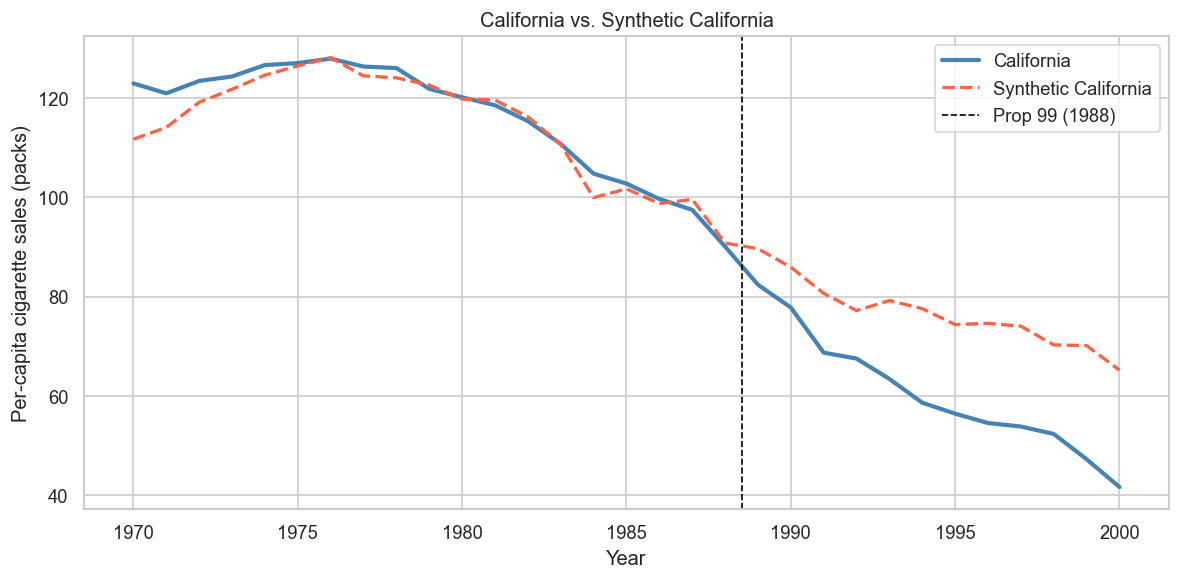

Pre-treatment RMSPE : 3.58 packs  (lower = better pre-treatment fit)


In [8]:
synthetic_ca = Y_0 @ w_opt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, Y_1,          color="steelblue", linewidth=2.5, label="California")
ax.plot(years, synthetic_ca, color="tomato",    linewidth=2,   linestyle="--", label="Synthetic California")
ax.axvline(T0 + 0.5, color="black", linestyle="--", linewidth=1, label="Prop 99 (1988)")
ax.set_xlabel("Year")
ax.set_ylabel("Per-capita cigarette sales (packs)")
ax.set_title("California vs. Synthetic California")
ax.legend()
plt.tight_layout()
plt.show()

pre_rmspe = np.sqrt(np.mean((Y_1[pre_mask] - synthetic_ca[pre_mask]) ** 2))
print(f"Pre-treatment RMSPE : {pre_rmspe:.2f} packs  (lower = better pre-treatment fit)")

## Gap plot

The gap $\hat{\alpha}_{1t} = Y_{1t} - \hat{Y}_{1t}$ is the estimated treatment effect in each year.
Near-zero pre-treatment gap confirms good pre-treatment fit.

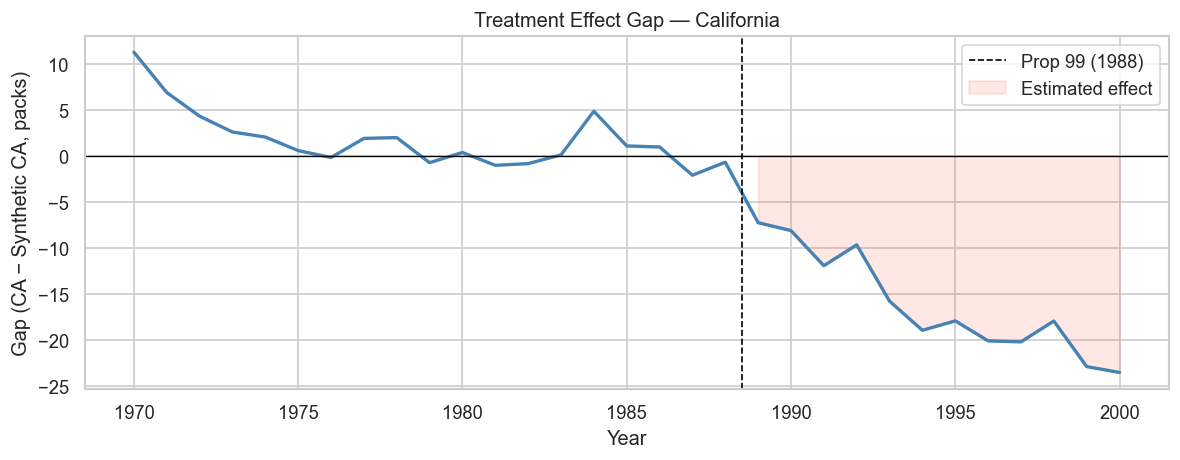

In [9]:
gap = Y_1 - synthetic_ca

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(years, gap, color="steelblue", linewidth=2)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(T0 + 0.5, color="black", linestyle="--", linewidth=1, label="Prop 99 (1988)")
ax.fill_between(years, gap, 0, where=post_mask, alpha=0.15, color="tomato", label="Estimated effect")
ax.set_xlabel("Year")
ax.set_ylabel("Gap (CA − Synthetic CA, packs)")
ax.set_title("Treatment Effect Gap — California")
ax.legend()
plt.tight_layout()
plt.show()

## ATT estimate

In [10]:
post_rmspe = np.sqrt(np.mean((Y_1[post_mask] - synthetic_ca[post_mask]) ** 2))
att_avg    = gap[post_mask].mean()
att_peak   = gap[post_mask].min()   # most negative year = largest reduction
att_peak_yr = years[post_mask][gap[post_mask].argmin()]

print(f"Pre-treatment RMSPE         : {pre_rmspe:.2f} packs")
print(f"Post-treatment RMSPE        : {post_rmspe:.2f} packs")
print(f"Average ATT (1989–2000)     : {att_avg:.1f} packs/year")
print(f"Peak ATT                    : {att_peak:.1f} packs/year ({att_peak_yr})")
print()
print("Prop 99 is associated with a reduction of ~{:.0f} packs/year on average,".format(abs(att_avg)))
print("peaking at ~{:.0f} packs/year in {:.0f}.".format(abs(att_peak), att_peak_yr))

Pre-treatment RMSPE         : 3.58 packs
Post-treatment RMSPE        : 17.09 packs
Average ATT (1989–2000)     : -16.2 packs/year
Peak ATT                    : -23.6 packs/year (2000)

Prop 99 is associated with a reduction of ~16 packs/year on average,
peaking at ~24 packs/year in 2000.


## Placebo inference — in-space placebo test

Synthetic control does not produce standard errors. Inference uses permutation logic:
apply the same procedure to every donor state (as if it were treated) and compare
California's post-treatment gap to the distribution of placebo gaps.

Placebos with very poor pre-treatment fit (RMSPE > 2× California's) are excluded —
a bad pre-fit means the method couldn't construct a valid synthetic for that state,
so its post-treatment gap is uninformative.

In [11]:
placebo_gaps   = {}
placebo_rmspes = {}

for sid in donor_ids:
    other_donors = [d for d in donor_ids if d != sid]

    Y_p_1 = Y_wide[sid].values
    Y_p_0 = Y_wide[other_donors].values

    X_p_1 = np.array(list(build_predictors(sid).values()))
    X_p_0 = np.array([list(build_predictors(d).values()) for d in other_donors]).T

    scale_p   = np.where(X_p_1 != 0, X_p_1, 1.0)
    X_p_1_n   = X_p_1 / scale_p
    X_p_0_n   = X_p_0 / scale_p[:, None]

    n_p  = len(other_donors)
    res_p = minimize(
        sc_loss, np.ones(n_p) / n_p, args=(X_p_1_n, X_p_0_n),
        method="SLSQP", bounds=[(0, 1)] * n_p,
        constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
        options={"ftol": 1e-12, "maxiter": 2000},
    )

    synth_p = Y_p_0 @ res_p.x
    gap_p   = Y_p_1 - synth_p

    placebo_gaps[sid]   = gap_p
    placebo_rmspes[sid] = np.sqrt(np.mean(gap_p[pre_mask] ** 2))

print(f"Placebo optimisations complete: {len(placebo_gaps)} states")

Placebo optimisations complete: 38 states


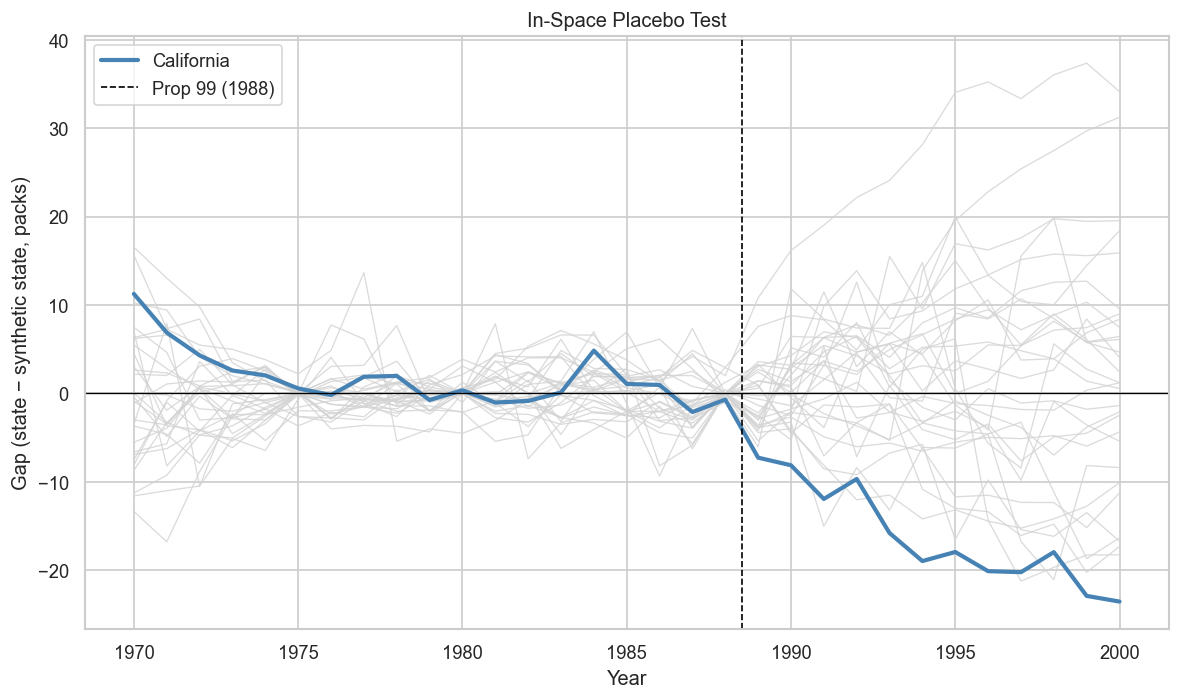

Placebos excluded (poor pre-fit): 9 of 38


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for sid, gap_p in placebo_gaps.items():
    if placebo_rmspes[sid] <= 2 * pre_rmspe:
        ax.plot(years, gap_p, color="lightgrey", linewidth=0.8, alpha=0.8)

ax.plot(years, gap, color="steelblue", linewidth=2.5, label="California")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(T0 + 0.5, color="black", linestyle="--", linewidth=1, label="Prop 99 (1988)")
ax.set_xlabel("Year")
ax.set_ylabel("Gap (state − synthetic state, packs)")
ax.set_title("In-Space Placebo Test")
ax.legend()
plt.tight_layout()
plt.show()

excluded = sum(1 for sid in donor_ids if placebo_rmspes[sid] > 2 * pre_rmspe)
print(f"Placebos excluded (poor pre-fit): {excluded} of {len(donor_ids)}")

## Post/Pre RMSPE ratio

The ratio of post-treatment RMSPE to pre-treatment RMSPE measures how unusual
California's post-treatment gap is relative to its pre-treatment fit.
A high ratio for California relative to the placebo distribution is evidence
that the post-treatment gap is not due to chance.

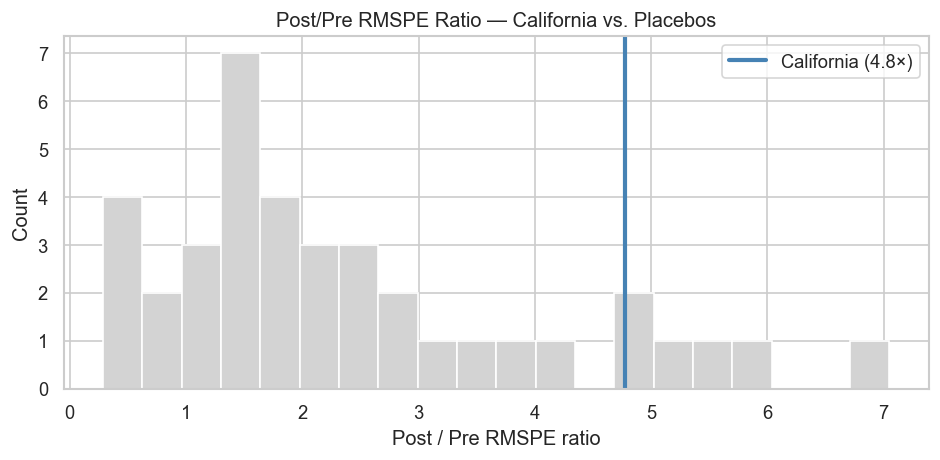

California post/pre RMSPE ratio : 4.77×
Permutation p-value             : 0.158


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Series'

In [13]:
rmspe_ratios = {}
for sid, gap_p in placebo_gaps.items():
    pre_p  = np.sqrt(np.mean(gap_p[pre_mask]  ** 2))
    post_p = np.sqrt(np.mean(gap_p[post_mask] ** 2))
    if pre_p > 0:
        rmspe_ratios[sid] = post_p / pre_p

ca_ratio  = post_rmspe / pre_rmspe
ratios_s  = pd.Series(rmspe_ratios).sort_values(ascending=False)
p_value   = (ratios_s >= ca_ratio).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratios_s.values, bins=20, color="lightgrey", edgecolor="white")
ax.axvline(ca_ratio, color="steelblue", linewidth=2.5, label=f"California ({ca_ratio:.1f}×)")
ax.set_xlabel("Post / Pre RMSPE ratio")
ax.set_ylabel("Count")
ax.set_title("Post/Pre RMSPE Ratio — California vs. Placebos")
ax.legend()
plt.tight_layout()
plt.show()

print(f"California post/pre RMSPE ratio : {ca_ratio:.2f}×")
print(f"Permutation p-value             : {p_value:.3f}")
print(f"  ({int(ratios_s >= ca_ratio).sum()} of {len(ratios_s)} placebo states have ratio ≥ California's)")
print()
print("Prop 99 reduced per-capita cigarette sales by an estimated")
print(f"~{abs(att_avg):.0f} packs/year on average over 1989–2000.")
print(f"California's post/pre RMSPE ratio ({ca_ratio:.1f}×) is in the tail of the placebo")
print(f"distribution (p = {p_value:.3f}), supporting a genuine treatment effect.")